# **SALARY PREDICTION USING MACHINE LEARNING**

This is a machine learning project developed **to predict an individual's expected salary based on various personal, educational, and professional factors**. The main objective of this project is to understand how different attributes such as age, gender, education level, job title, and years of experience influence salary and to use these relationships to generate salary predictions.

For this project, I worked with a salary dataset and performed the complete machine learning workflow, data preprocessing to exploratory data analysis, feature preparation, model training, and model evaluation. During the preprocessing stage, missing and inconsistent data were handled to improve the quality of the dataset. Exploratory data analysis was then performed using visualizations to understand the distribution of the data and identify relationships between different features and salary.

To build the prediction system, different regression algorithms were explored, including **Linear Regression, Decision Tree Regression, and Random Forest Regression**. The models were trained using the prepared dataset and evaluated using regression metrics such as **Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score**. Hyperparameter tuning was also considered to improve model performance.

In [50]:
#Loading the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [51]:
# Loading the .csv file into a dataframe

df = pd.read_csv("Salary_Data.csv")
df.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.00,Male,Bachelor's,Software Engineer,5.00,"90,000.00"
1,28.00,Female,Master's,Data Analyst,3.00,"65,000.00"
2,45.00,Male,PhD,Senior Manager,15.00,"150,000.00"
3,36.00,Female,Bachelor's,Sales Associate,7.00,"60,000.00"
4,52.00,Male,Master's,Director,20.00,"200,000.00"
5,29.00,Male,Bachelor's,Marketing Analyst,2.00,"55,000.00"
6,42.00,Female,Master's,Product Manager,12.00,"120,000.00"
7,31.00,Male,Bachelor's,Sales Manager,4.00,"80,000.00"
8,26.00,Female,Bachelor's,Marketing Coordinator,1.00,"45,000.00"
9,38.00,Male,PhD,Senior Scientist,10.00,"110,000.00"


In [52]:
#Checking the number of rows and columns, there are 6704 rows and 6 columns.

df.shape

(6704, 6)

In [53]:
# Dataframe contains float,string data types with null values in all columns.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 552.7 KB


In [54]:
# Checking the statistical summary of the numerical data

df.describe()

,Age,Years of Experience,Salary
count,"6,702.00","6,701.00","6,699.00"
mean,33.62,8.09,"115,326.96"
std,7.61,6.06,"52,786.18"
min,21.00,0.00,350.00
25%,28.00,3.00,"70,000.00"
50%,32.00,7.00,"115,000.00"
75%,38.00,12.00,"160,000.00"
max,62.00,34.00,"250,000.00"


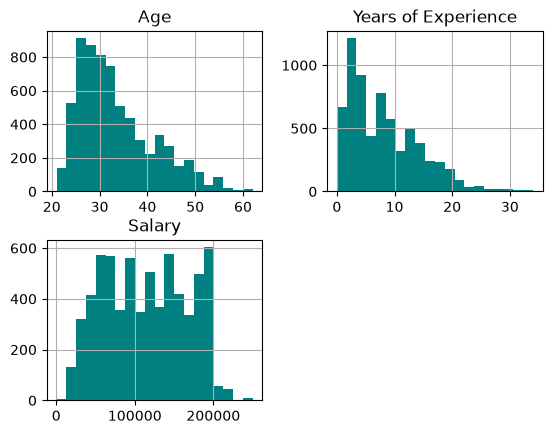

In [55]:
# Visualizing the distribution and spread of numerical features

df.hist(bins=20,color="teal")
plt.show()

In [56]:
# Checking if there are any null values. This dataframe has very few null values and they can be dropped.

df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [57]:
# Filtering the dataset to find rows containing null values

df[df.isnull().any(axis=1)]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
172,NaN,NaN,NaN,NaN,NaN,NaN
260,NaN,NaN,NaN,NaN,NaN,NaN
2011,27.00,Male,NaN,Developer,7.00,"100,000.00"
3136,31.00,Male,Master's Degree,Full Stack Engineer,8.00,NaN
5247,26.00,Female,Bachelor's Degree,Social M,NaN,NaN
6455,36.00,Male,Bachelor's Degree,Sales Director,6.00,NaN


In [58]:
# dropping rows with NA values

df = df.dropna(axis=0)

In [59]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [60]:
df["Education Level"].value_counts()

Education Level
Bachelor's Degree    2265
Master's Degree      1572
PhD                  1368
Bachelor's            756
High School           448
Master's              288
phD                     1
Name: count, dtype: int64

In [61]:
# Standardising category labels in "Education Level"

df["Education Level"] = df["Education Level"].replace({"Bachelor's":"Bachelor's Degree","Master's":"Master's Degree","phD" :"PhD"})
print(df["Education Level"].value_counts())

Education Level
Bachelor's Degree    3021
Master's Degree      1860
PhD                  1369
High School           448
Name: count, dtype: int64


In [62]:
# Displaying the frequency of each "Job Title" category

pd.set_option("display.max_rows", None)
print(df["Job Title"].value_counts())

Job Title
Software Engineer                        518
Data Scientist                           453
Software Engineer Manager                376
Data Analyst                             363
Senior Project Engineer                  318
Product Manager                          313
Full Stack Engineer                      308
Marketing Manager                        255
Senior Software Engineer                 244
Back end Developer                       244
Front end Developer                      241
Marketing Coordinator                    158
Junior Sales Associate                   142
Financial Manager                        134
Marketing Analyst                        132
Software Developer                       125
Operations Manager                       114
Human Resources Manager                  104
Director of Marketing                     88
Web Developer                             87
Product Designer                          75
Research Director                         75


In [63]:
# Standardising inconsistent "Job Title" categories

job_title_fixes = {
    
    # Spelling errors
    "Juniour HR Coordinator": "Junior HR Coordinator",
    "Juniour HR Generalist": "Junior HR Generalist",

    # Capitalization / formatting
    "Back end Developer": "Back End Developer",
    "Front end Developer": "Front End Developer",

    # Abbreviations / shortened titles
    "Customer Service Rep": "Customer Service Representative",
    "Customer Success Rep": "Customer Success Representative",

    # Clearly truncated titles
    "Social M": "Social Media Manager",
    "Social Media Man": "Social Media Manager",
     
    # HR naming consistency
    "Human Resources Coordinator": "HR Coordinator",
    "Human Resources Director": "HR Director",
    "HR Director": "Director of HR",
    "Director of Human Resources": "Director of HR",
    "Human Resources Manager": "HR Manager",
    "Senior Human Resources Coordinator": "Senior HR Coordinator",
    "Senior Human Resources Manager": "Senior HR Manager",
    "Senior Human Resources Specialist": "Senior HR Specialist",

    # Other Inconsistencies
    "Director of Marketing": "Marketing Director",
    "Director of Operations": "Operations Director",
    "Director of Sales": "Sales Director"
}

df["Job Title"] = df["Job Title"].replace(job_title_fixes)

In [64]:
# Saving all cleaned job title categories for the Streamlit app

all_job_titles = sorted(df["Job Title"].unique())

joblib.dump(
    all_job_titles,
    "all_job_titles.pkl"
)

print("Number of job titles:", len(all_job_titles))
print(all_job_titles)


Number of job titles: 179
['Account Manager', 'Accountant', 'Administrative Assistant', 'Back End Developer', 'Business Analyst', 'Business Development Manager', 'Business Intelligence Analyst', 'CEO', 'Chief Data Officer', 'Chief Technology Officer', 'Content Marketing Manager', 'Copywriter', 'Creative Director', 'Customer Service Manager', 'Customer Service Representative', 'Customer Success Manager', 'Customer Success Representative', 'Data Analyst', 'Data Entry Clerk', 'Data Scientist', 'Delivery Driver', 'Digital Content Producer', 'Digital Marketing Manager', 'Digital Marketing Specialist', 'Director', 'Director of Business Development', 'Director of Data Science', 'Director of Engineering', 'Director of Finance', 'Director of HR', 'Director of Human Capital', 'Director of Product Management', 'Director of Sales and Marketing', 'Event Coordinator', 'Financial Advisor', 'Financial Analyst', 'Financial Manager', 'Front End Developer', 'Full Stack Engineer', 'Graphic Designer', 'HR 

In [17]:
df["Job Title"].value_counts()

Job Title
Software Engineer                        518
Data Scientist                           453
Software Engineer Manager                376
Data Analyst                             363
Senior Project Engineer                  318
Product Manager                          313
Full Stack Engineer                      308
Front End Developer                      272
Marketing Manager                        255
Senior Software Engineer                 244
Back End Developer                       244
Marketing Coordinator                    158
Marketing Director                       152
Junior Sales Associate                   142
Financial Manager                        134
Marketing Analyst                        132
Software Developer                       125
Operations Manager                       114
HR Manager                               106
Web Developer                             87
Product Designer                          75
Research Director                         75


In [18]:
# There are 179 unique job titles, many showing up only once.
# Identifying job titles with 25 or fewer occurrences for potential removal.

job_title_count = df["Job Title"].value_counts()
job_title_reduced = job_title_count[job_title_count<=25]
job_title_reduced.count()

np.int64(132)

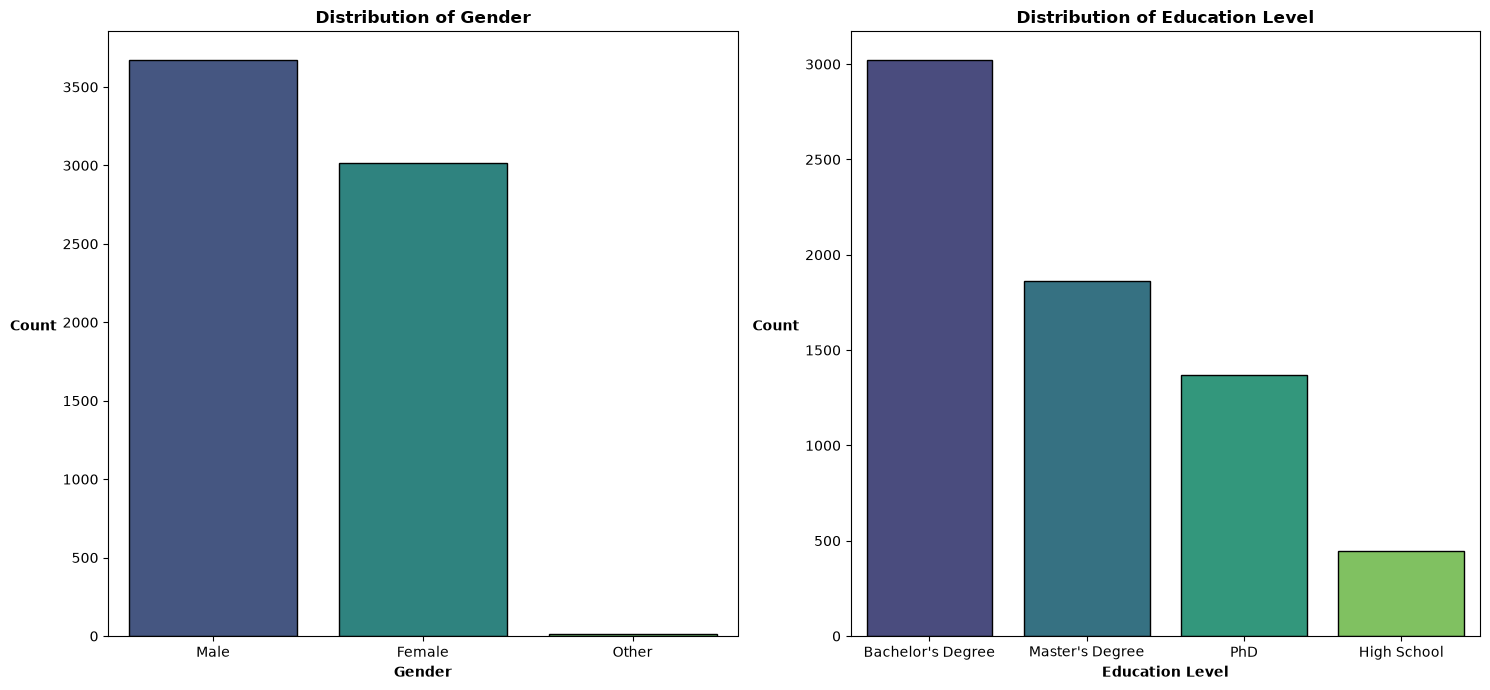

In [19]:
# Visualising the distribution of Gender and Education Level

fig, ax = plt.subplots(1, 2, figsize=(15, 7))

sns.countplot(x="Gender", data=df, ax=ax[0],hue="Gender",palette="viridis",ec="k")
ax[0].set_title("Distribution of Gender",fontweight="bold")
ax[0].set_xlabel("Gender",fontweight="bold")
ax[0].set_ylabel("Count",rotation=0, ha="right",fontweight="bold")

sns.countplot(x="Education Level", data=df, ax=ax[1],hue="Education Level",palette="viridis",ec="black")
ax[1].set_title("Distribution of Education Level",fontweight="bold")
ax[1].set_xlabel("Education Level",fontweight="bold")
ax[1].set_ylabel("Count",rotation=0, ha="right",fontweight="bold")

plt.tight_layout()
plt.show()

### Distribution of Gender and Education Level

1. **Distribution of Gender:** The dataset is predominantly male, followed by female employees, while employees belonging to other gender categories represent a very small proportion of the dataset. This indicates that the workforce represented in the dataset has a noticeable gender imbalance.

2. **Distribution of Education Level:** Most employees in the dataset hold a Bachelor's degree, followed by Master's and PhD qualifications, while high school graduates represent the smallest group. This indicates that bachelor's and master's degree holders make up a substantial proportion of the professionals represented in the dataset.

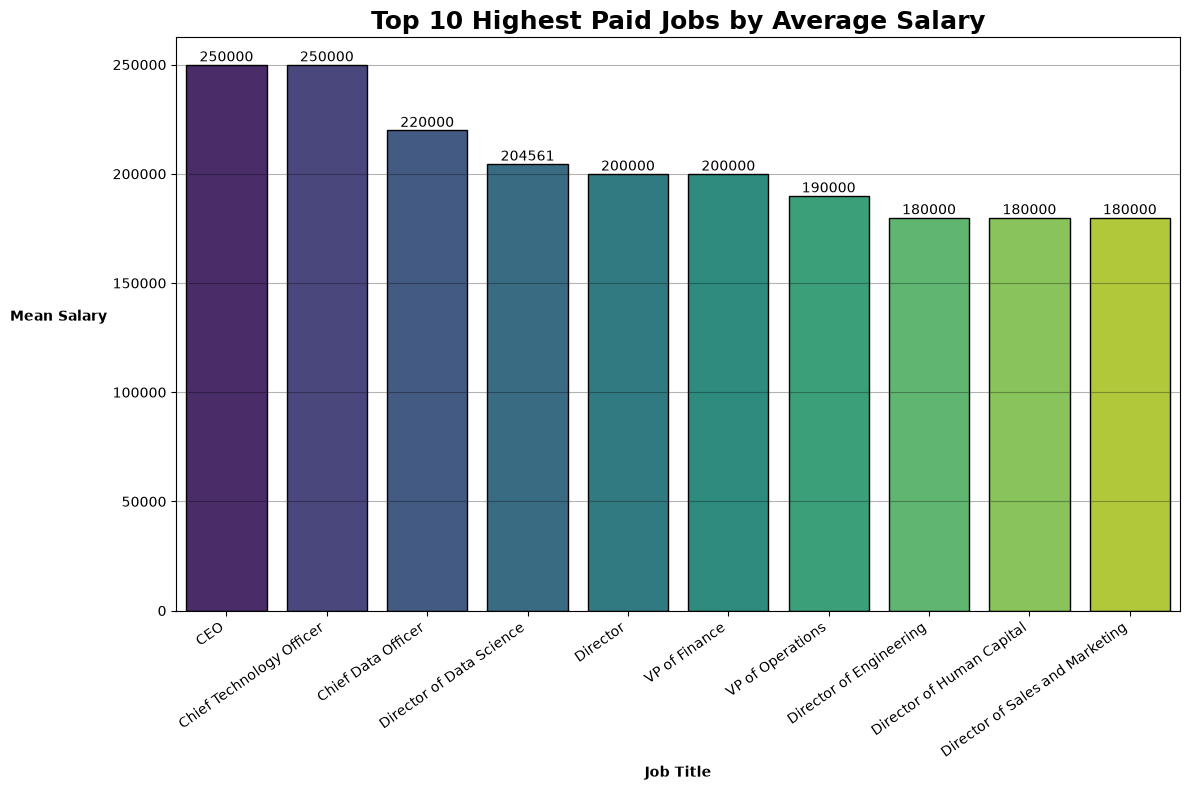

In [20]:
# Calculating the average salary for each job title and identifying the top 10 highest-paid roles

top_10_highest_paying_jobs = df.groupby("Job Title")["Salary"].mean().nlargest(10)

plt.figure(figsize=(12, 8))
bars = sns.barplot(x=top_10_highest_paying_jobs.index, y=top_10_highest_paying_jobs.values,hue=top_10_highest_paying_jobs.index, palette="viridis",ec="k")
plt.title("Top 10 Highest Paid Jobs by Average Salary",fontweight="bold",fontsize=18)
plt.xlabel("Job Title",fontweight="bold")
plt.ylabel("Mean Salary",fontweight="bold",rotation=0, ha="right")
plt.xticks(rotation=35, ha="right")

for container in bars.containers:
    plt.bar_label(container)

plt.grid(axis="y",color="black",alpha=0.3)
plt.tight_layout()
plt.show()

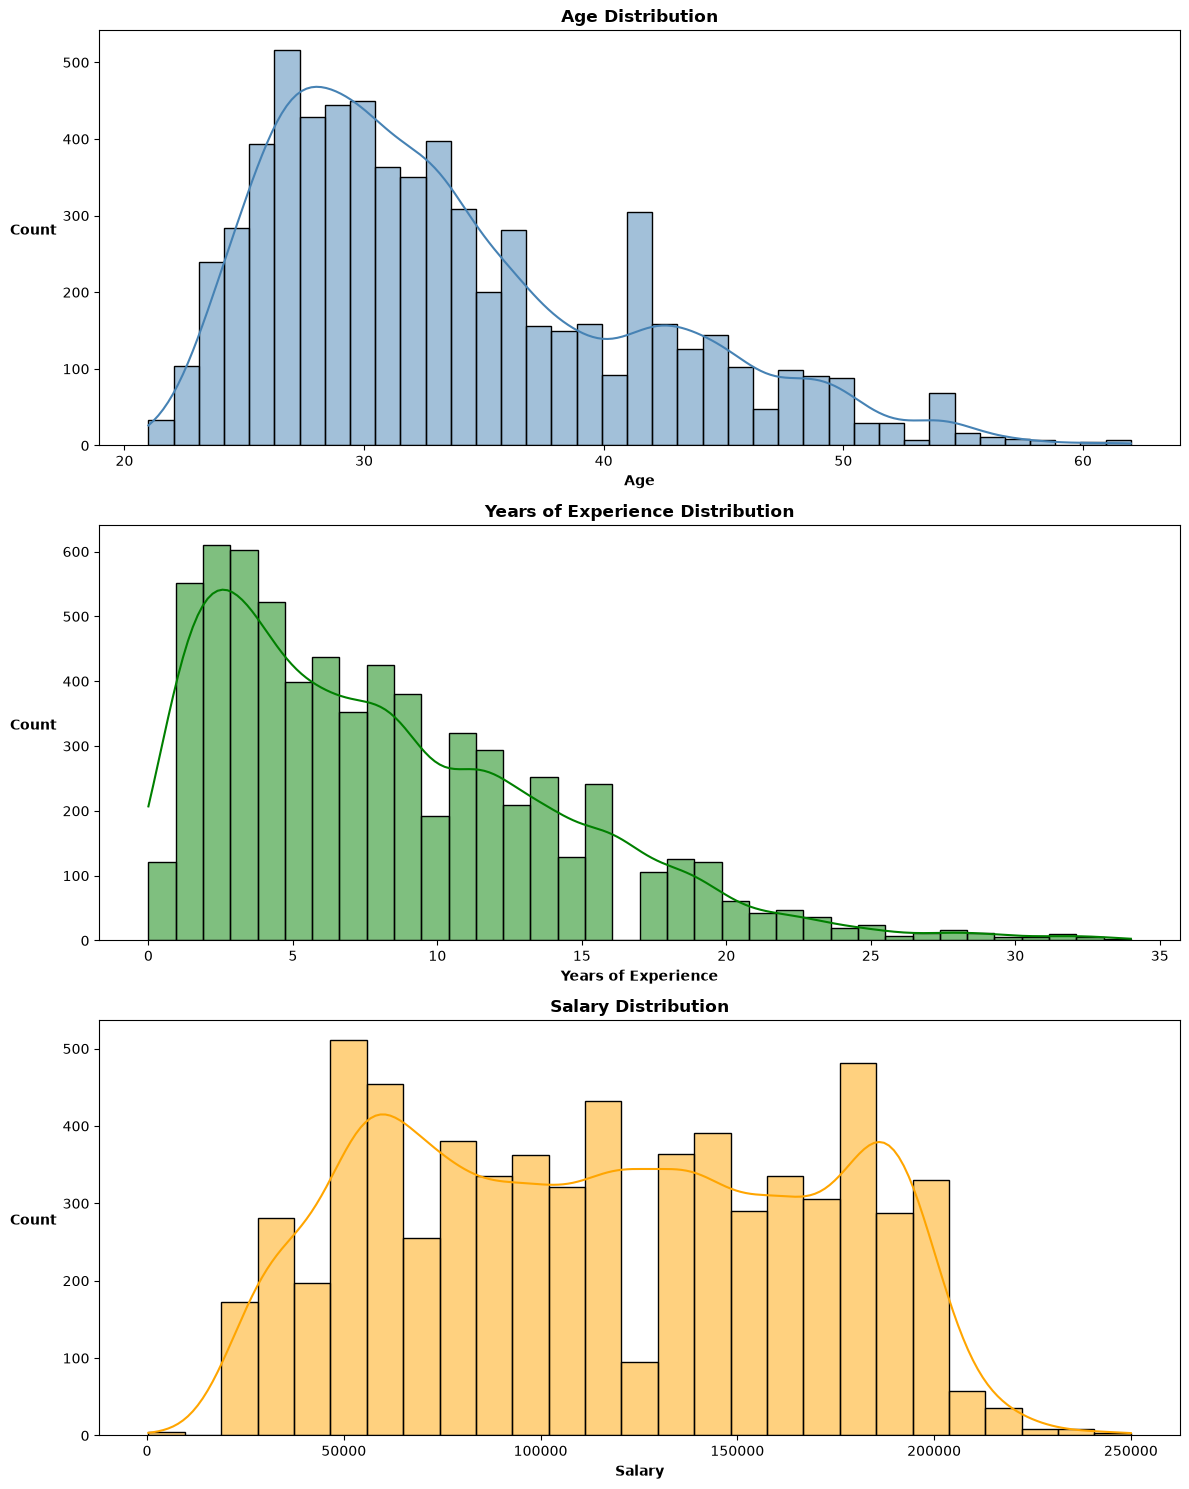

In [21]:
# Visualising the distributions of Age, Years of Experience, and Salary

fig, ax = plt.subplots(3, 1, figsize=(12, 15))

# Age distribution
sns.histplot(df["Age"], ax=ax[0], color="steelblue", kde=True)
ax[0].set_title("Age Distribution",fontweight="bold")
ax[0].set_xlabel("Age",fontweight="bold")
ax[0].set_ylabel("Count",fontweight="bold",ha="right",rotation=0)

# Years of Experience distribution
sns.histplot(df["Years of Experience"], ax=ax[1], color="green", kde=True)
ax[1].set_title("Years of Experience Distribution",fontweight="bold")
ax[1].set_xlabel('Years of Experience',fontweight="bold")
ax[1].set_ylabel("Count",fontweight="bold",ha="right",rotation=0)

# Salary distribution
sns.histplot(df["Salary"], ax=ax[2], color="orange", kde=True)
ax[2].set_title("Salary Distribution",fontweight="bold")
ax[2].set_xlabel("Salary",fontweight="bold")
ax[2].set_ylabel("Count",fontweight="bold",ha="right",rotation=0)

plt.tight_layout()
plt.show()

### Distribution of Continuous Variables

1. **Age Distribution:** The majority of employees fall within the 27–31 age range, indicating that the dataset is largely represented by younger working professionals.

2. **Years of Experience Distribution:** Most employees have between 1–4 years of professional experience. This is consistent with the age distribution, as employees in the younger age groups generally have fewer years of professional experience.

3. **Salary Distribution:** The salary distribution shows that a large proportion of employees earn between 50,000-60,000 Dollars annually. There is also a smaller concentration of employees earning around 180,000 Dollars. Overall, the distribution covers a wide range of salary levels, with the majority of employees earning below 125,000 Dollars per year.

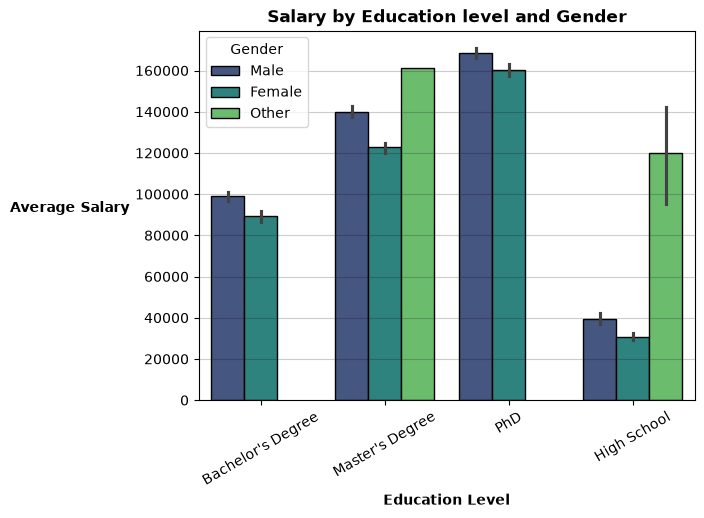

In [22]:
# Comparing mean salary across education levels by gender

sns.barplot(x="Education Level",y="Salary",data=df,hue="Gender",palette="viridis",ec="k")
plt.title("Salary by Education level and Gender",fontweight="bold")
plt.xticks(rotation=30)
plt.xlabel("Education Level",fontweight="bold")
plt.ylabel("Average Salary",fontweight="bold",rotation=0,ha="right")
plt.grid(axis="y",color="black",alpha=0.2)
plt.show()

### Relationship Between Education Level, Salary & Gender

The analysis shows differences in average salary across gender groups within the same education levels. In the dataset, male employees generally have higher average salaries than female employees at comparable education levels, while the other gender category shows higher average salaries in the education levels where it is represented. Additionally, average salary generally increases with higher levels of education, indicating a positive association between education level and salary in this dataset.  


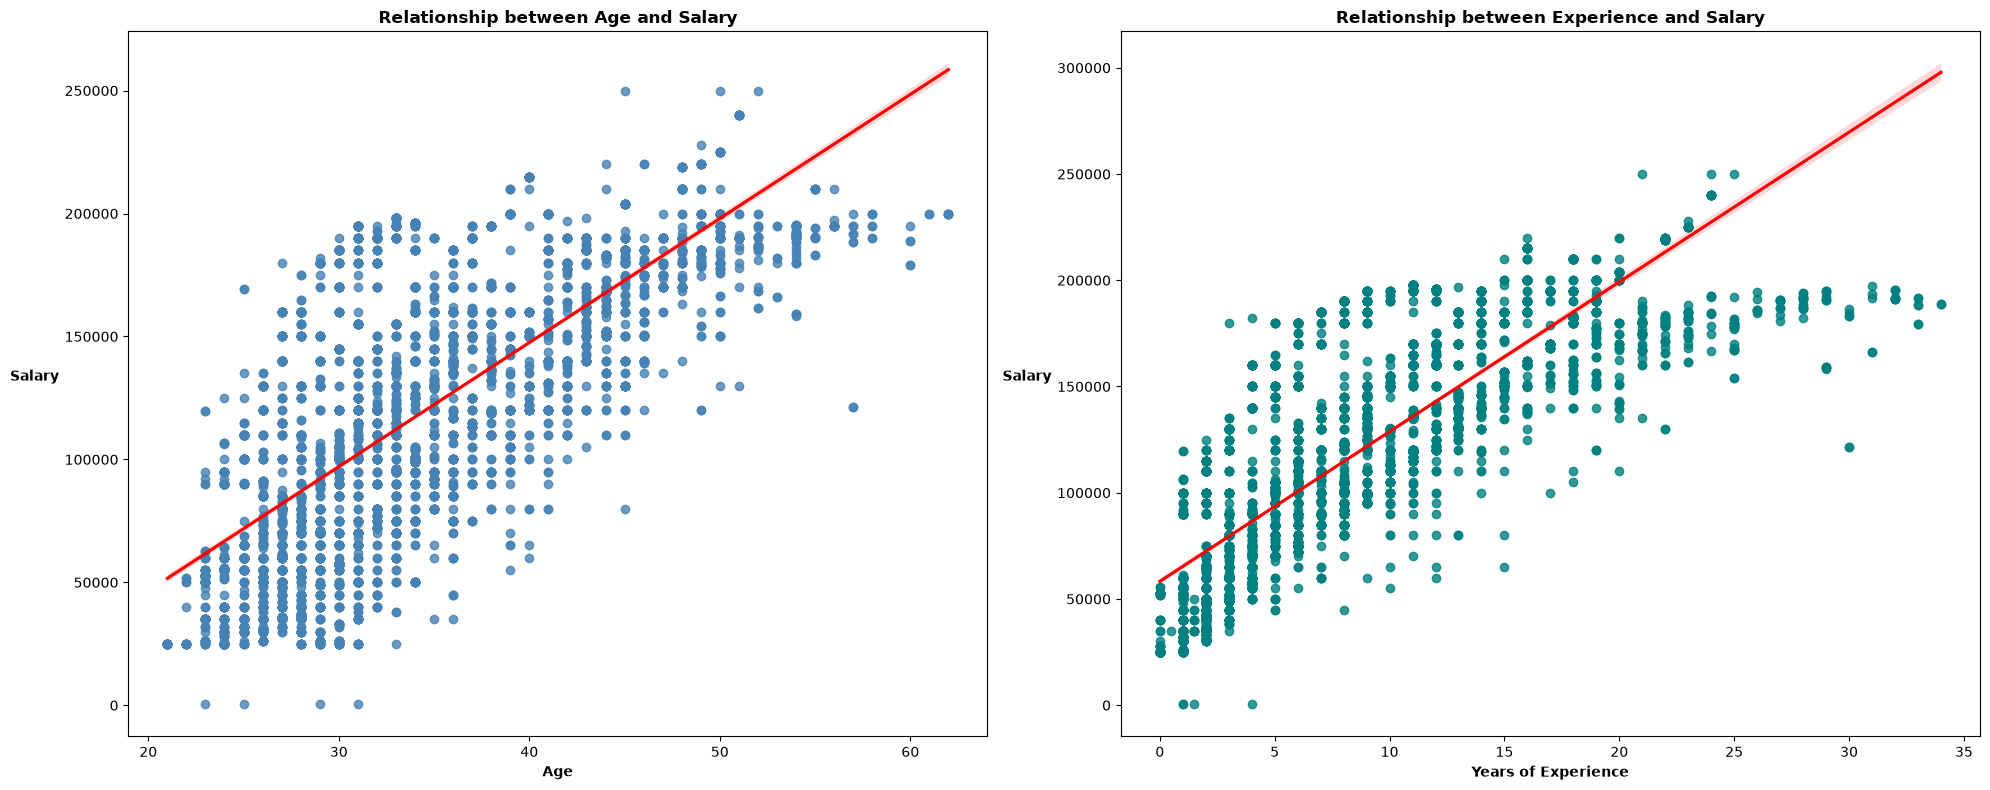

In [23]:
# Analysing the relationship between Salary and Age, and Salary and Years of Experience

fig, ax = plt.subplots(1,2,figsize=(20,8))

sns.regplot(x="Age", y="Salary", data=df,scatter_kws={"color":"steelblue"}, line_kws={"color":"red"},ax=ax[0])
ax[0].set_title("Relationship between Age and Salary",fontweight="bold")
ax[0].set_xlabel("Age",fontweight="bold")
ax[0].set_ylabel("Salary",fontweight="bold",rotation=0,ha="right")

sns.regplot(x="Years of Experience",y="Salary",data=df, scatter_kws={"color":"teal"},line_kws={"color":"red"},ax=ax[1])
ax[1].set_title("Relationship between Experience and Salary",fontweight="bold")
ax[1].set_xlabel("Years of Experience",fontweight="bold")
ax[1].set_ylabel("Salary",fontweight="bold",rotation=0,ha="right")

plt.tight_layout()
plt.show()

### Relationship Between Age, Experience and Salary

1. **Relationship between Age and Salary:** There is a strong positive correlation between age and salary, indicating that older employees in the dataset tend to have higher salaries than younger employees.

2. **Relationship between Experience and Salary:** There is a strong positive correlation between years of experience and salary, indicating that employees with more professional experience tend to earn higher salaries.

Overall, salary tends to increase as years of experience increase.

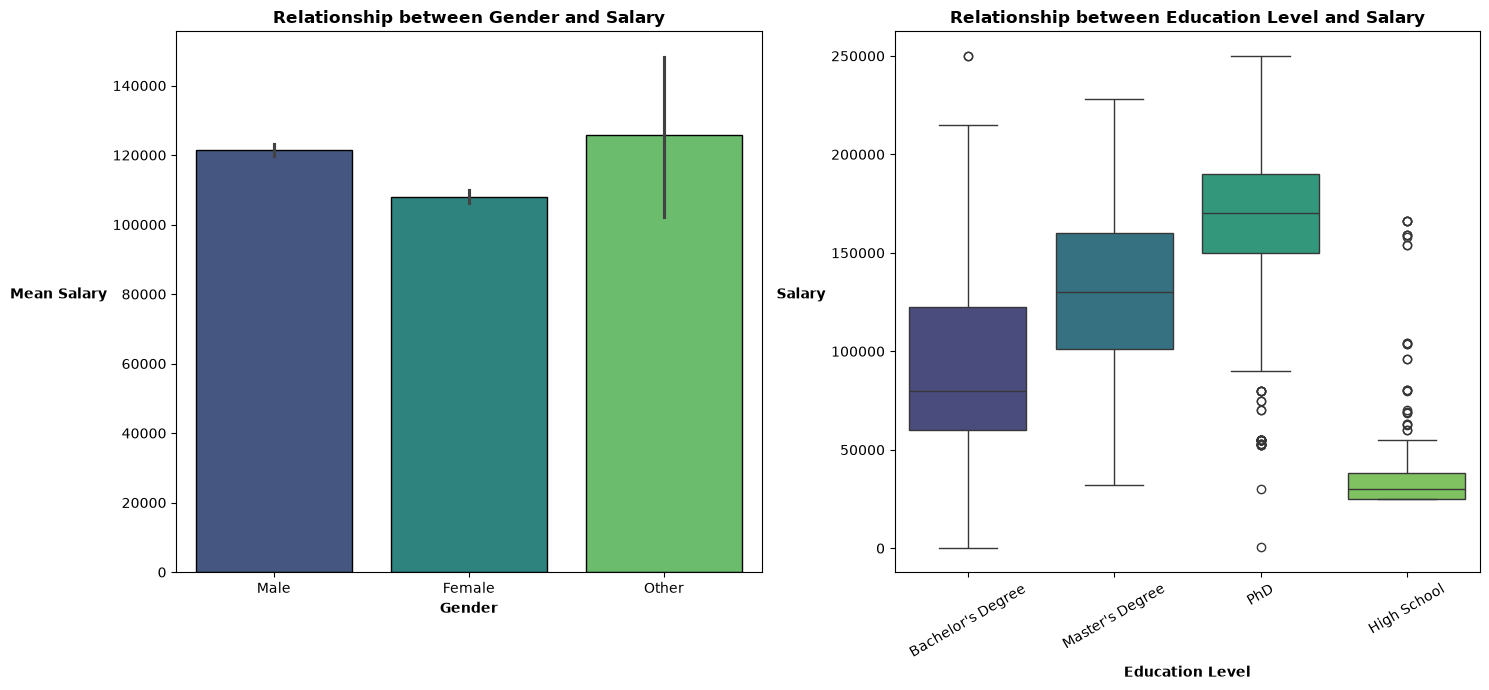

In [24]:
# Analysing the relationship between Salary and Gender, and Salary and Education Level

fig, ax = plt.subplots(1, 2, figsize=(15, 7))

sns.barplot(x="Gender",y="Salary",data=df,hue="Gender",palette="viridis",ec="k", ax=ax[0])
ax[0].set_title("Relationship between Gender and Salary",fontweight="bold")
ax[0].set_xlabel("Gender",fontweight="bold")
ax[0].set_ylabel("Mean Salary", rotation=0, ha="right",fontweight="bold")

sns.boxplot(x='Education Level', y="Salary", data=df, ax=ax[1],hue="Education Level",palette="viridis")
ax[1].set_title("Relationship between Education Level and Salary",fontweight="bold")
ax[1].tick_params(axis="x", rotation=30)
ax[1].set_xlabel("Education Level",fontweight="bold")
ax[1].set_ylabel("Salary", rotation=0, ha="right",fontweight="bold")

plt.tight_layout()
plt.show()

### Relationship Between Categorical Variables and Salary

1. **Gender and Salary:** The bar plot shows differences in mean salary across the gender categories. In this dataset, the other gender category has the highest mean salary, followed by male employees, while female employees have the lowest mean salary.

2. **Education Level and Salary:** The plot shows a positive relationship between education level and mean salary, with high school graduates having the lowest mean salary and PhD holders having the highest. The box plot also highlights the spread of salaries within each education category. The bachelor's degree category shows a relatively wide salary range, indicating greater variation in salaries, with some employees earning salaries comparable to those observed among master's degree holders.

In [25]:
df["Education Level"].value_counts()

Education Level
Bachelor's Degree    3021
Master's Degree      1860
PhD                  1369
High School           448
Name: count, dtype: int64

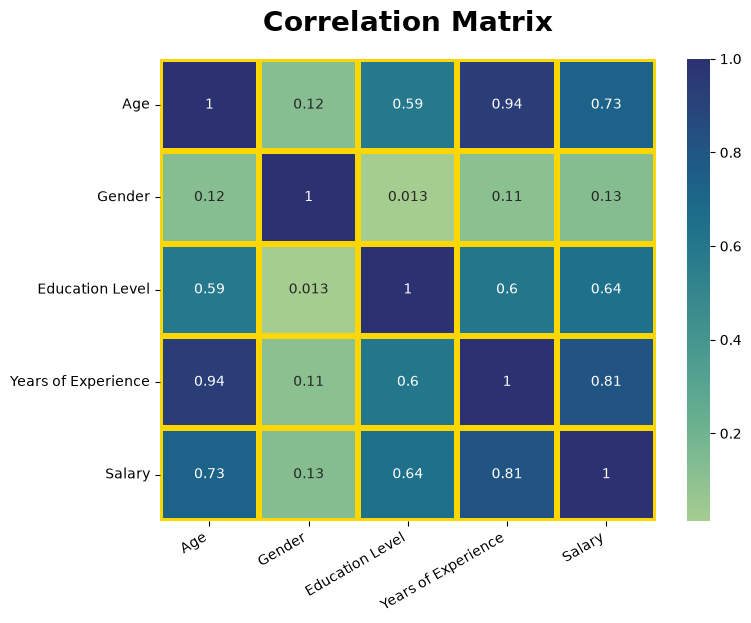

In [26]:
education_mapping = {"High School":0, "Bachelor's Degree":1, "Master's Degree":2, "PhD":3}
df["Education Level"] = df["Education Level"].map(education_mapping)

le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="crest",linecolor="gold",linewidth=3)
plt.title("Correlation Matrix",fontweight="bold", fontsize=20, pad=20)
plt.xticks(rotation=30,ha="right") 
plt.yticks(rotation=0) 
plt.show()

### Heatmap

The heatmap illustrates the strength and direction of the correlations between the numerical variables in the dataset.

1. **Age and Years of Experience:** The strongest correlation is observed between age and years of experience **(0.94)**, indicating that older employees generally tend to have more professional experience.

2. **Salary and Years of Experience:** Salary has a strong positive correlation with years of experience **(0.81)**, indicating that employees with more experience tend to have higher salaries.

3. **Salary and Age:** Salary also shows a strong positive correlation with age **(0.73)**, suggesting that older employees tend to earn higher salaries in the dataset.

4. **Salary and Education Level:** There is a moderately strong positive correlation between education level and salary **(0.64)**, indicating an association between higher education levels and higher salaries.

5. **Gender and Other Variables:** Gender shows relatively weak correlations with the other numerical variables, indicating little linear association between gender and these variables.

## **Predicting Salary**

Three machine learning regression models will be used to predict employee salaries:

1. **Linear Regression**
2. **Decision Tree Regression**
3. **Random Forest Regression**

The models will be evaluated using the following regression metrics:

* **R² Score:** Measures how well the model explains the variation in salary.
* **Mean Absolute Error (MAE):** Measures the average absolute difference between the actual and predicted salaries.
* **Mean Squared Error (MSE):** Measures the average squared difference between the actual and predicted salaries.
* **Root Mean Squared Error (RMSE):** Measures the square root of the average squared prediction error and is expressed in the same units as salary.

In [27]:
# Detecting outliers in the "Salary" column using the IQR method
# Calculating the Interquartile Range (IQR)
# Defining the lower and upper bounds for detecting outliers

Q1 = df["Salary"].quantile(0.25) # First Quartile
Q3 = df["Salary"].quantile(0.75) # Third Quartile
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

In [28]:
# Identifying salary values above the upper IQR boundary

df[df["Salary"]>upper]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary


**No Outliers in Q3**

In [29]:
# Identifying salary values below the lower IQR boundary

df[df["Salary"]<lower]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary


**No Outliers in Q1**

In [30]:
# Applying one-hot encoding to the "Job Title" categorical variable
# Adding the encoded job title columns to the DataFrame
# Removing the original "Job Title" column

dummies = pd.get_dummies(df['Job Title'],drop_first=True)
df = pd.concat([df,dummies],axis=1)
df.drop('Job Title',inplace=True,axis=1)
df.head()

,Age,Gender,Education Level,Years of Experience,Salary,Accountant,Administrative Assistant,Back End Developer,Business Analyst,Business Development Manager,...,Supply Chain Manager,Technical Recruiter,Technical Support Specialist,Technical Writer,Training Specialist,UX Designer,UX Researcher,VP of Finance,VP of Operations,Web Developer
0,32.0,1,1,5.0,90000.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,28.0,0,2,3.0,65000.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,45.0,1,3,15.0,150000.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,36.0,0,1,7.0,60000.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,52.0,1,2,20.0,200000.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [31]:
# Separating the dataset into features and target variable

features = df.drop("Salary",axis=1)
target = df["Salary"]                

In [32]:
# Splitting the data into 75% training and 25% test set
# Checking the shape of the training set

x_train,x_test,y_train,y_test = train_test_split(features,target,test_size=0.25,random_state=42)
x_train.shape

(5023, 182)

In [33]:
# Defining machine learning models and hyperparameters for tuning

model_params = {
    
    "Linear_Regression": {"model": LinearRegression(),"params": {}},
    
    "Decision_Tree": {"model": DecisionTreeRegressor(),"params": {"max_depth": [2, 4, 6, 8, 10],
                                                                  "min_samples_split": [2, 5, 10, 20]}},
    
    "Random_Forest": {"model": RandomForestRegressor(),"params": {"n_estimators": [10, 20, 30, 50, 80]}}
}

In [34]:
# Performing hyperparameter tuning using GridSearchCV with 5-fold cross-validation

score=[]

for model_name,m in model_params.items():
    clf = GridSearchCV(m["model"],m["params"],cv=5,scoring="neg_mean_squared_error")
    clf.fit(x_train,y_train)
    
    score.append({"Model":model_name,
                  "Params":clf.best_params_,
                  "MSE":-clf.best_score_ 
                 })

pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.2f}".format)
pd.DataFrame(score)

,Model,Params,MSE
0,Linear_Regression,{},"468,748,546.95"
1,Decision_Tree,"{'max_depth': 10, 'min_samples_split': 2}","153,592,108.38"
2,Random_Forest,{'n_estimators': 80},"66,175,700.25"


In [35]:
# Sorting models by MSE to compare their cross-validation performance

results = pd.DataFrame(score)
results_sorted = results.sort_values(by = "MSE",ascending=True)
results_sorted

,Model,Params,MSE
2,Random_Forest,{'n_estimators': 80},"66,175,700.25"
1,Decision_Tree,"{'max_depth': 10, 'min_samples_split': 2}","153,592,108.38"
0,Linear_Regression,{},"468,748,546.95"


In [36]:
# Initialising and training the Random Forest regression model

rfr = RandomForestRegressor(n_estimators=50)
rfr.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numbe

In [37]:
# Evaluating the Random Forest model on the test set using R² score
print("\n-----Random Forest Regressor-----")
print("\nR² score is:",round(rfr.score(x_test,y_test),3))

# Generating predictions on the test set
# Calculating regression evaluation metrics

y_pred_rfr = rfr.predict(x_test)

mae = mean_absolute_error(y_test, y_pred_rfr)
mse = mean_squared_error(y_test, y_pred_rfr)
rmse = np.sqrt(mse)

print("Mean Absolute Error :", round(mae,2))
print("Mean Squared Error  :", round(mse,2))
print("Root Mean Squared Error :", round(rmse,2))


-----Random Forest Regressor-----

R² score is: 0.973
Mean Absolute Error : 3289.06
Mean Squared Error  : 75756665.21
Root Mean Squared Error : 8703.83


In [38]:
# Initialising and training the Decision Tree regression model using the selected hyperparameters

dtr = DecisionTreeRegressor(max_depth=10,min_samples_split=2,random_state=42)
dtr.fit(x_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes ma

In [39]:
# Evaluating the Decision Tree model on the test set using R² score

print("\n-----Decision Tree Regressor-----")
print("\nR² score is:",round(dtr.score(x_test,y_test),3))

# Generating predictions on the test set
# Calculating regression evaluation metrics

y_pred_dtr = dtr.predict(x_test)

mse = mean_squared_error(y_test, y_pred_dtr)
mae = mean_absolute_error(y_test, y_pred_dtr)
rmse = np.sqrt(mse)

print("Mean Absolute Error :", round(mae,2))
print("Mean Squared Error  :", round(mse,2))
print("Root Mean Squared Error :", round(rmse,2))


-----Decision Tree Regressor-----

R² score is: 0.941
Mean Absolute Error : 7456.31
Mean Squared Error  : 167148048.49
Root Mean Squared Error : 12928.57


In [40]:
# Initialising and training the Linear Regression model

lr = LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](182,)","[ 478.16, -770.94, 5131.02,...,45137.09,35137.09,-6995. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](182,)","['Age','Gender','Education Level',...,'VP of Finance','VP of Operations', 'Web Developer']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.121e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,182
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(157)


In [41]:
# Evaluating the Linear Regression model on the test set using R² score

print("\n-----Linear Regression-----")
print("\nR² score is:",round(lr.score(x_test,y_test),3))

# Generating predictions on the test set
#  Calculating regression evaluation metrics

y_pred_lr = lr.predict(x_test)

mse = mean_squared_error(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)

print("Mean Absolute Error :", round(mae,2))
print("Mean Squared Error  :", round(mse,2))
print("Root Mean Squared Error :", round(rmse,2))


-----Linear Regression-----

R² score is: 0.833
Mean Absolute Error : 15717.66
Mean Squared Error  : 476471881.94
Root Mean Squared Error : 21828.24


In [42]:
sorted_feature_importances = dict(sorted(zip(rfr.feature_names_in_, rfr.feature_importances_), key= lambda x: x[1],reverse= True))
top_15_features = dict(list(sorted_feature_importances.items())[:15])

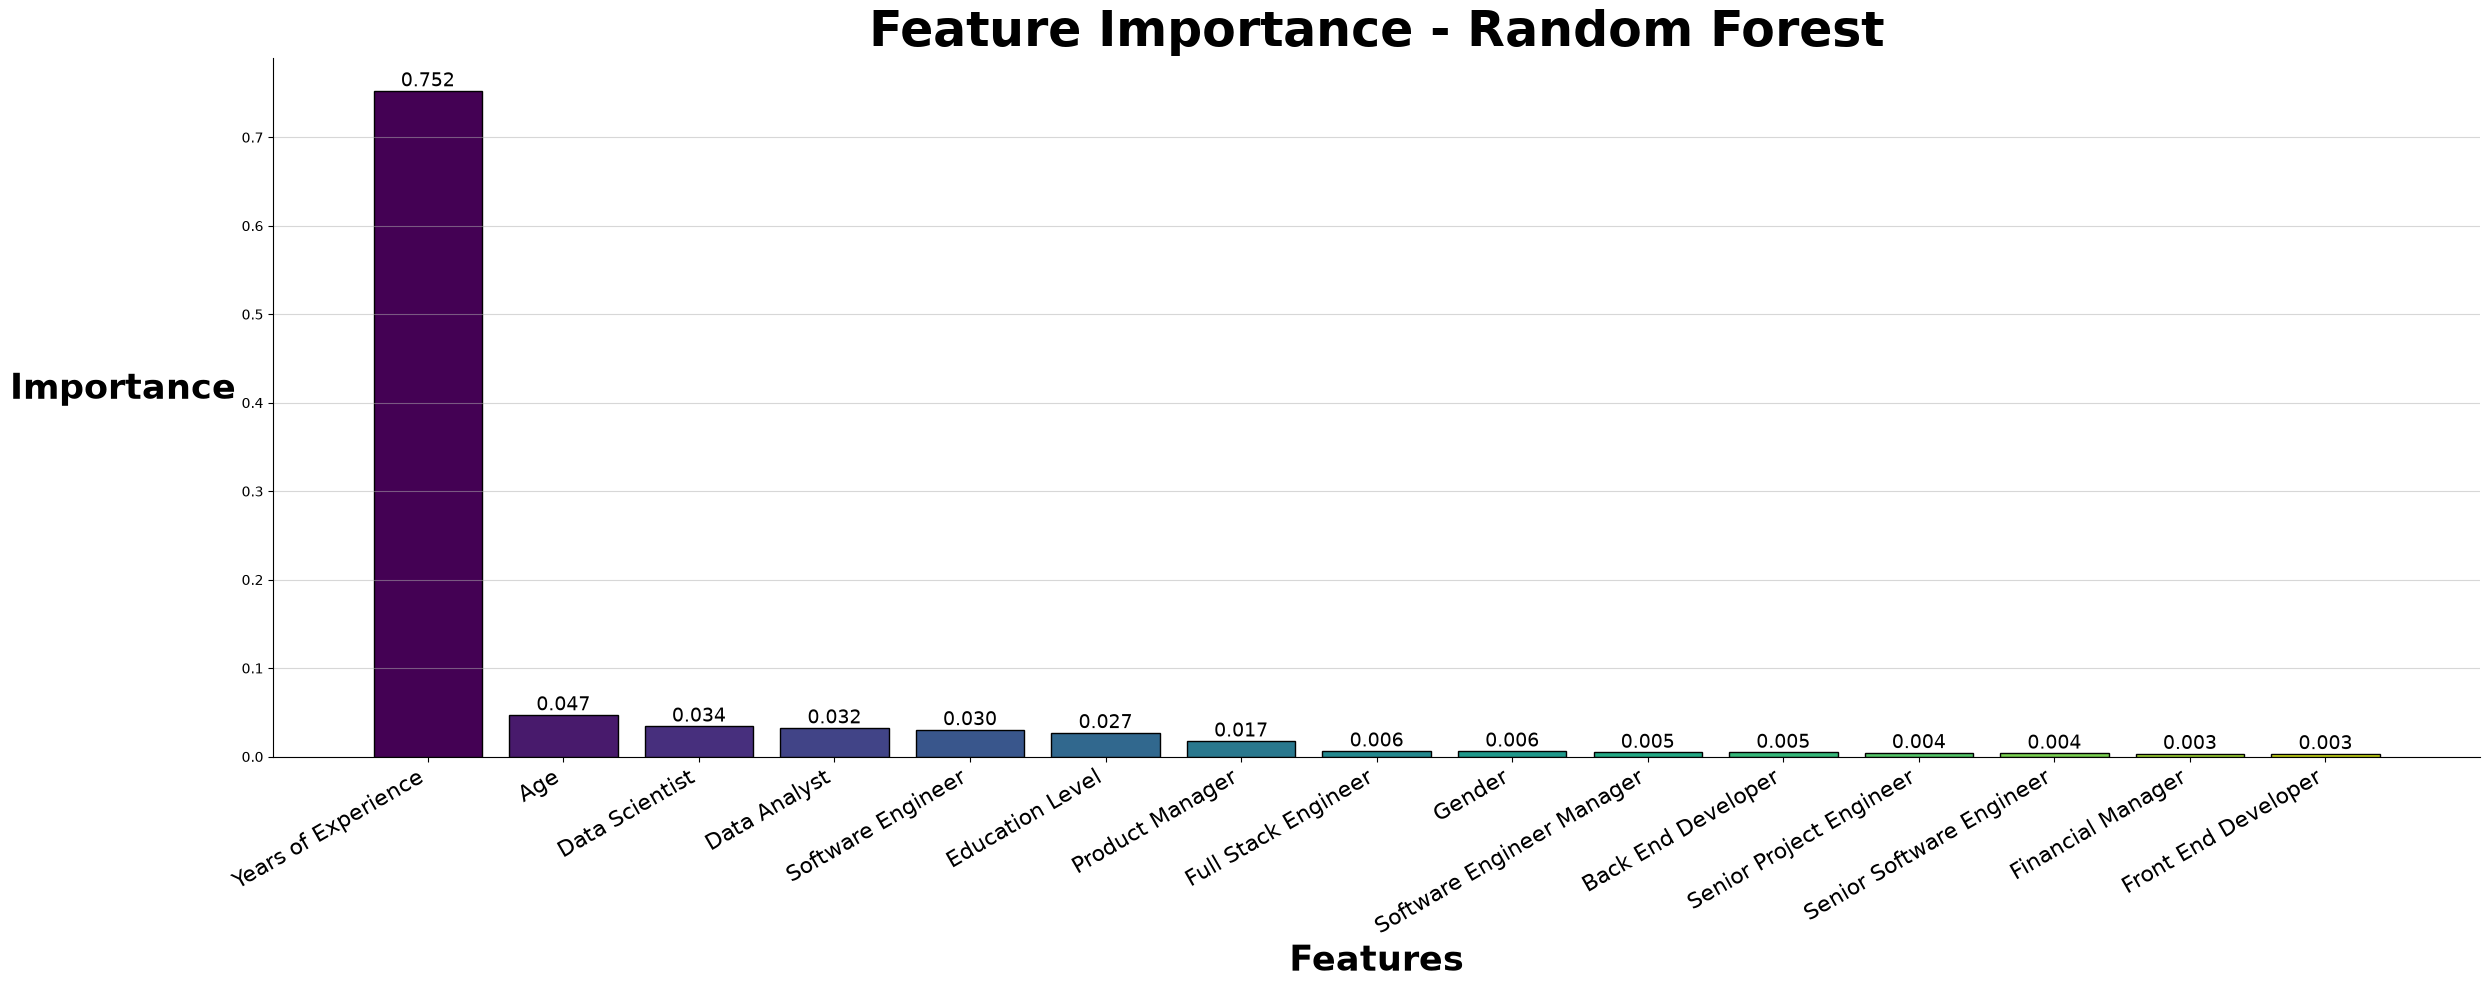

In [43]:
# Visualising the top 15 most important features

plt.figure(figsize=(25,10))
colors = [plt.cm.viridis(i / len(top_15_features)) for i in range(len(top_15_features))]
bars = plt.bar(top_15_features.keys(), top_15_features.values(),color=colors,ec="k")
plt.title("Feature Importance - Random Forest",fontsize = 35, fontweight = "bold")
plt.xlabel("Features",fontsize=25,fontweight = "bold")
plt.ylabel("Importance",fontsize=25,fontweight = "bold", rotation=0, ha="right")
plt.xticks(rotation=30, ha="right",fontsize=16)
plt.bar_label(bars, fmt="%.3f", fontsize=14)
plt.grid(axis="y", linestyle="-",alpha=0.5)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# **Conclusion**
1. The **Random Forest model** achieved the highest **R-squared score of 0.973** and the lowest MSE, MAE, and RMSE values, indicating the best predictive performance among the three models.

2. The Decision Tree model performed well with an **R-squared score of 0.941** but had higher errors compared to the Random Forest.

3. The Linear Regression model had the lowest **R-squared score of 0.833** and the highest errors, suggesting it may not capture the underlying patterns in the data as effectively as the ensemble models.

In conclusion, the Random Forest model appears to be the most suitable for predicting salaries in this dataset, as it offers the highest predictive accuracy and the lowest error metrics. Further optimization and fine-tuning of the Random Forest model could potentially lead to even better results.

In [44]:
# Saving the Random Forest Regressor Model

joblib.dump(rfr, "random_forest.pkl")

['random_forest.pkl']

In [45]:
joblib.dump(le, "gender_encoder.pkl")

['gender_encoder.pkl']

In [46]:
education_mapping = {
    "High School": 0,
    "Bachelor's Degree": 1,
    "Master's Degree": 2,
    "PhD": 3
}

joblib.dump(education_mapping, "education_mapping.pkl")

['education_mapping.pkl']

In [47]:
job_title_columns = dummies.columns.tolist()

joblib.dump(job_title_columns, "job_title_columns.pkl")

['job_title_columns.pkl']

In [48]:
feature_columns = features.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']